<a href="https://colab.research.google.com/github/MoeezAmir93/deeplearning/blob/main/final%20lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)


In [11]:
# Initialize weights and biases for 3 layers
def initialize_parameters():
    W1 = np.random.randn(2, 2) * 0.1
    b1 = np.zeros((2, 1))
    W2 = np.random.randn(2, 2) * 0.1
    b2 = np.zeros((2, 1))
    W3 = np.random.randn(2, 2) * 0.1
    b3 = np.zeros((2, 1))
    return W1, b1, W2, b2, W3, b3

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid (used in backpropagation)
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


In [12]:
# Input and target vectors
X = np.array([[0.5], [0.8]])  # Input (2x1)
R = np.array([[0.2], [0.9]])  # Target Output (2x1)

# Hyperparameters
epochs = 5
learning_rate = 0.1

# Initialize weights and biases
W1, b1, W2, b2, W3, b3 = initialize_parameters()

# List to store error over epochs
errors = []


In [13]:
# Training loop for multiple epochs
for epoch in range(epochs):
    # ---- FORWARD PASS ----
    Z1 = np.dot(W1, X) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)

    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)

    # Calculate squared error
    error = 0.5 * np.sum((A3 - R)**2)
    errors.append(error)

    # ---- BACKWARD PASS ----
    # Output layer gradient
    delta3 = (A3 - R) * sigmoid_derivative(Z3)
    dW3 = np.dot(delta3, A2.T)
    db3 = np.sum(delta3, axis=1, keepdims=True)

    # Hidden layer 2 gradient
    delta2 = np.dot(W3.T, delta3) * sigmoid_derivative(Z2)
    dW2 = np.dot(delta2, A1.T)
    db2 = np.sum(delta2, axis=1, keepdims=True)

    # Hidden layer 1 gradient
    delta1 = np.dot(W2.T, delta2) * sigmoid_derivative(Z1)
    dW1 = np.dot(delta1, X.T)
    db1 = np.sum(delta1, axis=1, keepdims=True)

    # ---- UPDATE WEIGHTS ----
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    # ---- PRINT DEBUG INFO ----
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("Z1:\n", Z1)
    print("A1:\n", A1)
    print("Z2:\n", Z2)
    print("A2:\n", A2)
    print("Z3:\n", Z3)
    print("A3:\n", A3)
    print("Error:", error)
    print("Delta3:\n", delta3)
    print("Delta2:\n", delta2)
    print("Delta1:\n", delta1)
    print("Updated W3:\n", W3)
    print("Updated b3:\n", b3)
    print("Updated W2:\n", W2)
    print("Updated b2:\n", b2)
    print("Updated W1:\n", W1)
    print("Updated b1:\n", b1)



Epoch 1/5
Z1:
 [[0.01377456]
 [0.15422682]]
A1:
 [[0.50344359]
 [0.53848046]]
Z2:
 [[-0.02439612]
 [ 0.12082932]]
A2:
 [[0.49390127]
 [0.53017063]]
Z3:
 [[ 0.00557754]
 [-0.04757988]]
A3:
 [[0.50139438]
 [0.48810727]]
Error: 0.13024709592316808
Delta3:
 [[ 0.07534801]
 [-0.10291492]]
Delta2:
 [[0.00030792]
 [0.0022122 ]]
Delta1:
 [[8.55317880e-05]
 [4.03998743e-05]]
Updated W3:
 [[-0.05066889  0.05026127]
 [-0.04125879 -0.04111673]]
Updated b3:
 [[-0.0075348 ]
 [ 0.01029149]]
Updated W2:
 [[-0.02343084 -0.02343028]
 [ 0.15780991  0.07662435]]
Updated b2:
 [[-3.07920097e-05]
 [-2.21219984e-04]]
Updated W1:
 [[ 0.04966714 -0.01383327]
 [ 0.06476683  0.15229975]]
Updated b1:
 [[-8.55317880e-06]
 [-4.03998743e-06]]

Epoch 2/5
Z1:
 [[0.0137584 ]
 [0.15421918]]
A1:
 [[0.50343955]
 [0.53847856]]
Z2:
 [[-0.0244435]
 [ 0.1204871]]
A2:
 [[0.49388943]
 [0.53008539]]
Z3:
 [[-0.00591686]
 [-0.03188116]]
A3:
 [[0.49852079]
 [0.49203038]]
Error: 0.12777693447228247
Delta3:
 [[ 0.07462954]
 [-0.10196

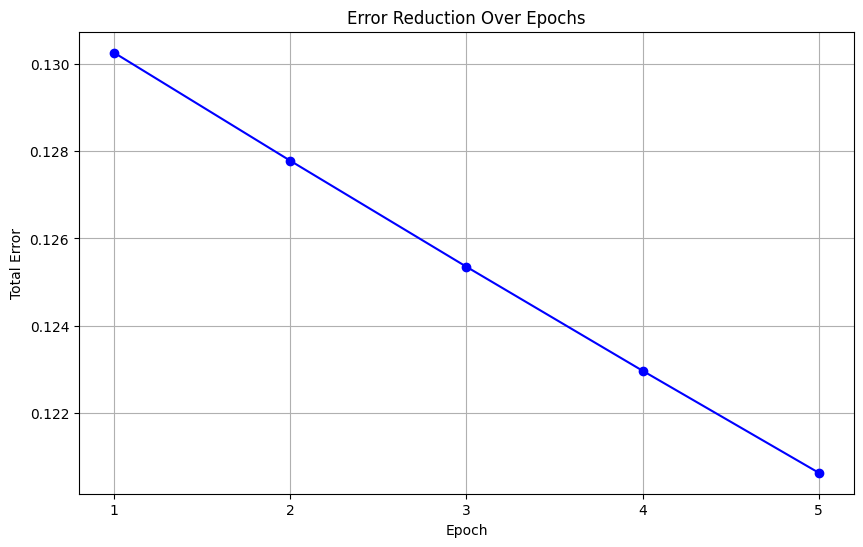

In [14]:
# Plot error over each epoch
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), errors, marker='o', linestyle='-', color='b')
plt.title('Error Reduction Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Total Error')
plt.grid(True)
plt.xticks(range(1, epochs+1))
plt.show()


/tmp/ipython-input-9-693467744.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(values[i])


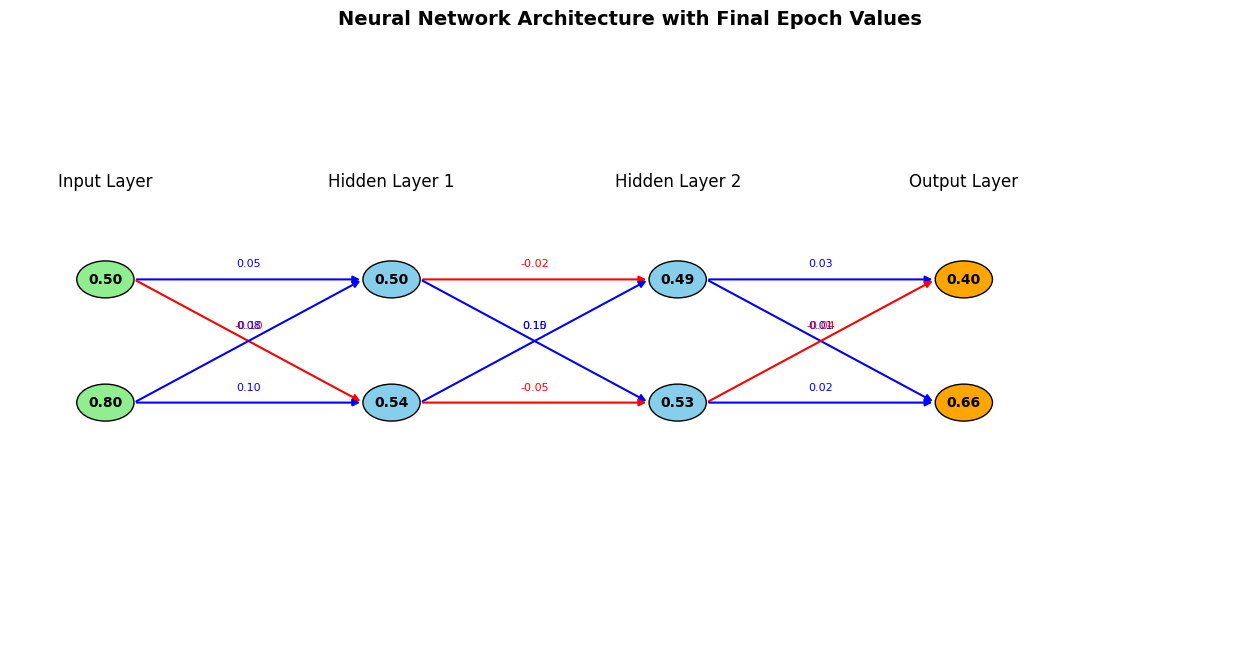

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
import numpy as np

def draw_network_with_values(X, Z1, A1, Z2, A2, Z3, A3, W1, b1, W2, b2, W3, b3):
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.axis('off')
    ax.set_xlim(-1, 12)
    ax.set_ylim(-5, 5)
    radius = 0.3

    # Neuron positions
    layer_positions = {
        'input': [(0, 1), (0, -1)],
        'hidden1': [(3, 1), (3, -1)],
        'hidden2': [(6, 1), (6, -1)],
        'output': [(9, 1), (9, -1)],
    }

    # Draw neurons with values
    def draw_neurons(layer_name, values, color='skyblue'):
        for i, (x, y) in enumerate(layer_positions[layer_name]):
            value = float(values[i])
            circle = Circle((x, y), radius, color=color, ec='black', zorder=4)
            ax.add_patch(circle)
            ax.text(x, y, f"{value:.2f}", fontsize=10, ha='center', va='center', zorder=5, fontweight='bold')

    # Draw layers
    draw_neurons('input', X, 'lightgreen')
    draw_neurons('hidden1', A1, 'skyblue')
    draw_neurons('hidden2', A2, 'skyblue')
    draw_neurons('output', A3, 'orange')

    # Draw connections with weights
    def draw_connections(from_layer, to_layer, weights):
        for i, (x1, y1) in enumerate(layer_positions[from_layer]):
            for j, (x2, y2) in enumerate(layer_positions[to_layer]):
                w = weights[j, i]
                color = 'red' if w < 0 else 'blue'
                line = FancyArrowPatch((x1 + radius, y1), (x2 - radius, y2),
                                       arrowstyle='-|>', color=color, lw=1.5, mutation_scale=10)
                ax.add_patch(line)
                mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
                ax.text(mid_x, mid_y + 0.2, f"{w:.2f}", fontsize=8, ha='center', color=color)

    draw_connections('input', 'hidden1', W1)
    draw_connections('hidden1', 'hidden2', W2)
    draw_connections('hidden2', 'output', W3)

    # Add layer titles
    ax.text(0, 2.5, "Input Layer", fontsize=12, ha='center')
    ax.text(3, 2.5, "Hidden Layer 1", fontsize=12, ha='center')
    ax.text(6, 2.5, "Hidden Layer 2", fontsize=12, ha='center')
    ax.text(9, 2.5, "Output Layer", fontsize=12, ha='center')

    plt.title("Neural Network Architecture with Final Epoch Values", fontsize=14, fontweight='bold')
    plt.show()

# === CALL THIS AFTER THE LAST EPOCH OF YOUR CODE ===
# At the end of training loop (after epoch 5)
draw_network_with_values(
    X=X,
    Z1=Z1, A1=A1,
    Z2=Z2, A2=A2,
    Z3=Z3, A3=A3,
    W1=W1, b1=b1,
    W2=W2, b2=b2,
    W3=W3, b3=b3
)
